# Assignment - Unsupervise Learning
In this assignment, we apply clustering and dimension reduction on Breast Cancer dataset from scikit-learn.
We will explore:

1. **Clustering**: find potential group in the data.
2. **PCA**: reduce feature dimensions while keeping important information
3. **Model comparison**: check performance before and after PCA

## 1. Introduction & Setup
1. Load Breast Cancer dataset from scikit-learn.
2. Understand and explore the data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load data as a DataFrame
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Unsupervised Learning Task: Clustering

#### Separate features (X) and target (Y), find potential groups on input features (X) using k-means.

Clustering algorithms are scale-sensitive, so normalize data first.

In [3]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

#### TODO: 
1. Build k-means model.
2. Evaluate through SSE or Silhouette and visualize it.
3. Find `K` for k-means

c:\Users\Jannatul Yea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Jannatul Yea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Jannatul Yea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Jannatul Yea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to 

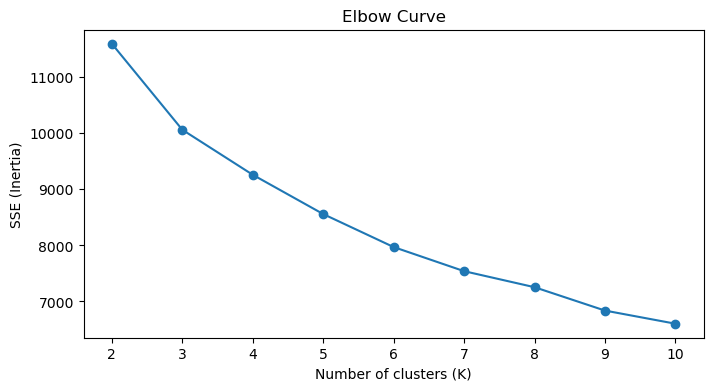

c:\Users\Jannatul Yea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Silhouette Score for K=2: 0.3434


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 1: Elbow Curve দিয়ে best K খোঁজো
sse = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_norm)
    sse.append(km.inertia_)  # inertia = SSE

# Plot
plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Curve')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.show()

# Step 2: Best K দিয়ে final model
best_k = 2  # elbow দেখে ঠিক করো, সম্ভবত 2 হবে
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_norm)

# Step 3: Silhouette score দেখো
score = silhouette_score(X_norm, kmeans.labels_)
print(f'Silhouette Score for K={best_k}: {score:.4f}')

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

# TODO: Fit normalized X to K-means


# TODO: Evaluate K-means and plot the result (Elbow curve of SSE or silhouette plot (See lecture slide: AI1_M1_Lec8_Clustering_I, page 32))




## Supervised Learning Task: Classification with/without dimension reduction

#### Step1: Split into train/test and normalize.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape :', X_test_scaled.shape)

Train shape: (455, 30)
Test shape : (114, 30)


#### Step 2: Apply PCA on input data

TODO:
1. Fit PCA on normalized training data.
2. Visualize the importance of principal components though scree plot.
3. Transform train/test data to reduced dimensions.

Components needed for 95% variance: 10


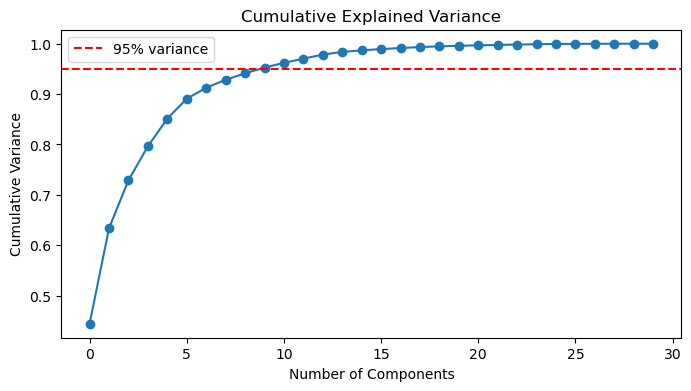

Original shape: (455, 30)
PCA shape: (455, 10)


In [10]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train_scaled)


cum_var = np.cumsum(pca_full.explained_variance_ratio_)


n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f'Components needed for 95% variance: {n_components_95}')

plt.figure(figsize=(8, 4))
plt.plot(cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.show()

pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Original shape:', X_train_scaled.shape)
print('PCA shape:', X_train_pca.shape)

In [6]:
from sklearn.decomposition import PCA

# TODO: fit PCA() on X_train_scaled
# pca_full = ...
# pca_full.fit(...)

# TODO: compute cumulative explained variance
# cum_var = ...
# n_components_95 = ...

# TODO: print number of components

# TODO: plot cumulative explained variance curve with 95% horizontal line

# TODO: fit PCA with selected components and transform train/test
# pca = ...
# X_train_pca = ...
# X_test_pca = ...

# TODO: print original and PCA train shapes

#### Step 3: Classification before and after PCA
Train a classifier (e.g. Logistic Regression, Random Forest, etc) on:
1. Original scaled features
2. PCA-reduced features
Then compare test accuracy.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Original data দিয়ে
model_original = LogisticRegression(max_iter=10000)
model_original.fit(X_train_scaled, y_train)
y_pred_original = model_original.predict(X_test_scaled)
acc_original = accuracy_score(y_test, y_pred_original)

# PCA data দিয়ে
model_pca = LogisticRegression(max_iter=10000)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f'Accuracy (Original): {acc_original:.4f}')
print(f'Accuracy (PCA):      {acc_pca:.4f}')
print('\nClassification Report (PCA model):')
print(classification_report(y_test, y_pred_pca))

Accuracy (Original): 0.9825
Accuracy (PCA):      0.9737

Classification Report (PCA model):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Questions
Answer briefly:
1. Which `K` did you choose for K-Means, and why?
2. How many principal components were needed for 95% variance?
3. Did PCA improve or reduce the test accuracy? Why might that happen?
4. Why did we normalize data before K-means and PCA?

In [ ]:
# Write your short answers here as Python comments
# Q1: I chose K=2 because the Elbow curve showed a clear bend at K=2,
#     and the Breast Cancer dataset naturally has 2 groups (malignant
#     and benign). Silhouette Score for K=2 was 0.3434, which confirms
#     a reasonable clustering.

# Q2: 10 principal components were needed to retain 95% of the variance.
#     This reduced the features from 30 down to 10.

# Q3: PCA slightly reduced the accuracy from 0.9825 to 0.9737.
#     This is because PCA removes some information (5% variance).
#     However, the difference is very small (~1%), meaning PCA
#     successfully compressed the data without major information loss.

# Q4: K-Means and PCA are both distance-based algorithms. Without
#     normalization, features with large numeric values would dominate
#     over features with small values, giving incorrect results.
#     StandardScaler ensures all features contribute equally.